In [6]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


## Imports & Version Check

Run this cell once before starting the assignment to import packages.

In [7]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
import plotly

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("plotly:", plotly.__version__)

import matplotlib.pyplot as plt
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


In [8]:
def plot_initial_step(f_int, K_t, f_ext, u1, u_plot):
    """
    Plot iteration 0:
      - tangent stiffness at u = 0
      - first linearized estimate u^(1)
    """
    y_curve = f_int(u_plot)

    u0 = 0.0
    f_int_0 = f_int(u0)
    K0 = K_t(u0)

    tangent_0 = f_int_0 + K0 * (u_plot - u0)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Nonlinear curve
    ax.plot(u_plot, y_curve, linewidth=2, label="nonlinear solution")

    # External load
    ax.axhline(f_ext, linestyle="--", linewidth=1.5, label=r"$f_f$")

    # Initial point
    ax.plot(u0, f_int_0, "o", markersize=8, label=r"$u_f^{(0)}$")

    # Initial tangent
    ax.plot(u_plot, tangent_0, linewidth=1.5, label=r"$K_{ff,t}^{(0)}$ tangent")

    # First approximation
    ax.plot(u1, f_ext, "o", markersize=8, label=r"$u_f^{(1)}$")

    ax.axvline(u0, linestyle="--", linewidth=1.0)
    ax.axvline(u1, linestyle="--", linewidth=1.0)

    # Horizontal correction arrow from u^(0) to u^(1)
    ax.annotate(
        "",
        xy=(u1, f_ext),
        xytext=(u0, f_ext),
        arrowprops=dict(arrowstyle="->", lw=2),
    )
    ax.text(
        0.5 * (u0 + u1),
        f_ext + 0.03 * max(y_curve.max(), f_ext),
        r"first approximation",
        ha="center",
        fontsize=11,
    )

    y_text = ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
    x_shift = 0.02 * (u_plot.max() - u_plot.min())

    ax.text(u0+2*x_shift, y_text, r"$u_f^{(0)}$", ha="center", fontsize=12)
    ax.text(u1+x_shift, y_text, r"$u_f^{(1)}$", ha="center", fontsize=12)

    ax.set_xlabel("Deformation", fontsize=12)
    ax.set_ylabel("Load", fontsize=12)
    ax.set_title("Newton-Raphson: Iteration 0", fontsize=14)
    ax.set_xlim(u_plot.min(), u_plot.max())
    ax.set_ylim(min(0.0, y_curve.min()) - 0.2, max(y_curve.max(), f_ext) * 1.15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()



In [9]:
def plot_newton_iteration(f_int, K_t, f_ext, u_i, u_next, du_i, r_i, i, u_plot):
    """
    Plot iteration i >= 1.
    """
    y_curve = f_int(u_plot)
    K_i = K_t(u_i)
    f_int_i = f_int(u_i)

    tangent_line = f_int_i + K_i * (u_plot - u_i)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Nonlinear curve
    ax.plot(u_plot, y_curve, linewidth=2, label="nonlinear solution")

    # External load
    ax.axhline(f_ext, linestyle="--", linewidth=1.5, label=r"$f_f$")

    # Current internal force level
    ax.axhline(f_int_i, linestyle="--", linewidth=1.0)

    # Vertical lines
    ax.axvline(u_i, linestyle="--", linewidth=1.0)
    ax.axvline(u_next, linestyle="--", linewidth=1.0)

    # Current point
    ax.plot(u_i, f_int_i, "o", markersize=8, label=rf"$f_{{f,\mathrm{{int}}}}^{{({i})}}$")

    # Tangent line
    ax.plot(u_plot, tangent_line, linewidth=1.5, label=rf"$K_{{ff,t}}^{{({i})}}$ tangent")

    # Next point
    ax.plot(u_next, f_ext, "o", markersize=8)

    # Residual arrow
    ax.annotate(
        "",
        xy=(u_i, f_ext),
        xytext=(u_i, f_int_i),
        arrowprops=dict(arrowstyle="<-", lw=2),
    )
    ax.text(
        u_i - 0.06 * (u_plot.max() - u_plot.min()),
        0.5 * (f_ext + f_int_i),
        rf"$\mathbf{{r}}^{{({i})}}$",
        fontsize=12,
        va="center",
    )

    # Correction arrow
    ax.annotate(
        "",
        xy=(u_next, f_ext),
        xytext=(u_i, f_ext),
        arrowprops=dict(arrowstyle="->", lw=2),
    )
    ax.text(
        0.5 * (u_i + u_next),
        f_ext + 0.03 * max(y_curve.max(), f_ext),
        rf"$\Delta \mathbf{{u}}_f^{{({i})}}$",
        fontsize=12,
        ha="center",
    )

    y_text = ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
    x_shift = 0.02 * (u_plot.max() - u_plot.min())

    ax.text(u_i+x_shift, y_text, rf"$u_f^{{({i})}}$", ha="center", fontsize=12)
    ax.text(u_next+x_shift, y_text, rf"$u_f^{{({i+1})}}$", ha="center", fontsize=12)

    ax.set_xlabel("Deformation", fontsize=12)
    ax.set_ylabel("Load", fontsize=12)
    ax.set_title(f"Newton-Raphson: Iteration {i}", fontsize=14)
    ax.set_xlim(u_plot.min(), u_plot.max())
    ax.set_ylim(min(0.0, y_curve.min()) - 0.2, max(y_curve.max(), f_ext) * 1.15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

In [10]:
def newton_raphson_1d(
    f_int,
    K_t,
    f_ext,
    tol=1e-3,
    max_iter=20,
    u_plot=None,
    make_plots=True,
):
    """
    Solve:
        r(u) = f_ext - f_int(u) = 0

    using Newton-Raphson:
        K_t(u^(i)) Δu^(i) = r^(i)
        u^(i+1) = u^(i) + Δu^(i)

    Includes an explicit iteration 0 plot showing:
      - K_t^(0) at u^(0) = 0
      - first approximation u^(1)
    """

    if u_plot is None:
        u_plot = np.linspace(0.0, 4.0, 500)

    history = []

    # ---------------------------------------------------------
    # Step 1
    # initialize with tangent stiffness matrix at 0 deformation
    # K_ff,t^(0)
    # ---------------------------------------------------------
    u0 = 0.0
    K0 = K_t(u0)

    if abs(K0) < 1e-14:
        raise ValueError("Initial tangent stiffness K_t(0) is zero.")

    # ---------------------------------------------------------
    # Step 2
    # solve for u_f^(1) as a linearized first estimate
    # u_f^(1) = K_ff,t^{-1(0)} f_f
    # ---------------------------------------------------------
    u = f_ext / K0   # this is u^(1)

    history.append(
        {
            "iter": 0,
            "u_i": u0,
            "f_int_i": f_int(u0),
            "r_i": f_ext - f_int(u0),
            "K_i": K0,
            "du_i": u,
            "u_next": u,
            "conv_measure": np.nan,
            "converged": False,
        }
    )

    if make_plots:
        plot_initial_step(f_int, K_t, f_ext, u, u_plot)

    # ---------------------------------------------------------
    # Steps 3-9
    # repeat until converged
    # ---------------------------------------------------------
    for i in range(1, max_iter + 1):

        # -----------------------------------------------------
        # Step 3
        # compute internal force f_f,int^(i)
        # -----------------------------------------------------
        f_int_i = f_int(u)

        # -----------------------------------------------------
        # Step 4
        # compute residual r^(i) = f_f - f_f,int^(i)
        # -----------------------------------------------------
        r_i = f_ext - f_int_i

        # -----------------------------------------------------
        # Step 5
        # form the new tangent stiffness K_ff,t^(i)
        # -----------------------------------------------------
        K_i = K_t(u)

        if abs(K_i) < 1e-14:
            raise ValueError(f"Tangent stiffness is zero at iteration {i}.")

        # -----------------------------------------------------
        # Step 6
        # solve Δu_f^(i) = K_ff,t^{-1(i)} r^(i)
        # -----------------------------------------------------
        du_i = r_i / K_i

        # -----------------------------------------------------
        # Step 7
        # update u_f^(i+1) = u_f^(i) + Δu_f^(i)
        # -----------------------------------------------------
        u_next = u + du_i

        # -----------------------------------------------------
        # Step 8
        # check convergence
        # here using a simple displacement-based criterion
        # -----------------------------------------------------
        denom = max(abs(u), 1e-14)
        conv_measure = abs(du_i) / denom
        converged = conv_measure <= tol

        history.append(
            {
                "iter": i,
                "u_i": u,
                "f_int_i": f_int_i,
                "r_i": r_i,
                "K_i": K_i,
                "du_i": du_i,
                "u_next": u_next,
                "conv_measure": conv_measure,
                "converged": converged,
            }
        )

        if make_plots:
            plot_newton_iteration(
                f_int=f_int,
                K_t=K_t,
                f_ext=f_ext,
                u_i=u,
                u_next=u_next,
                du_i=du_i,
                r_i=r_i,
                i=i,
                u_plot=u_plot,
            )

        # -----------------------------------------------------
        # Step 9
        # if not converged, repeat steps 3-8
        # -----------------------------------------------------
        if converged:
            return history, u_next, True

        u = u_next

    return history, u, False

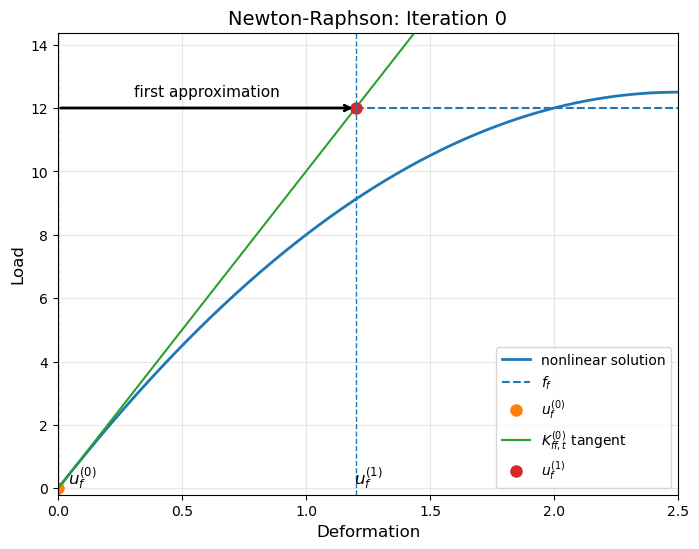

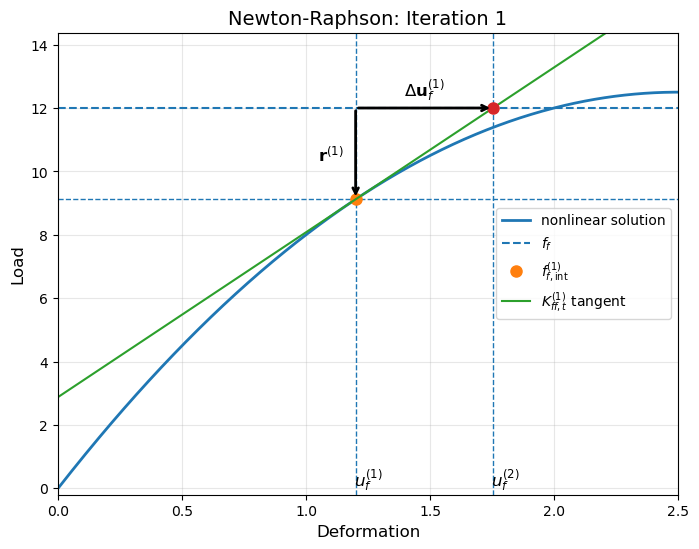

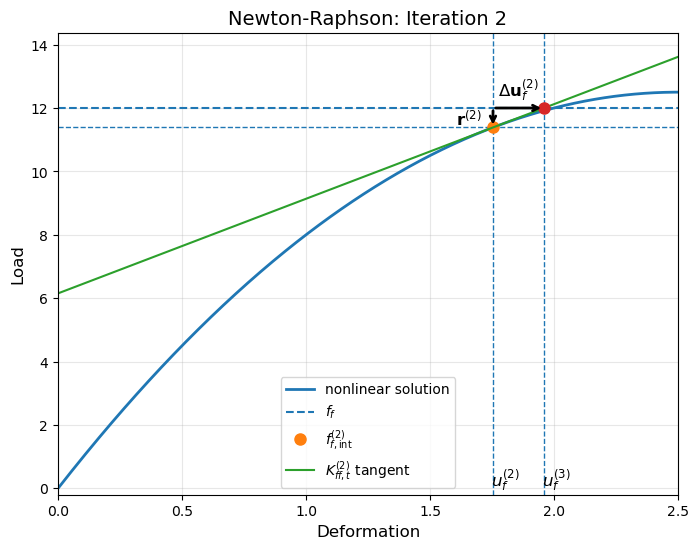

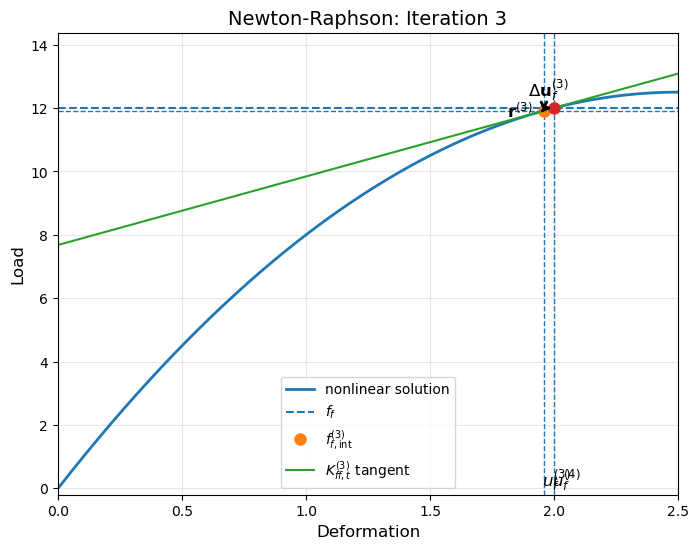

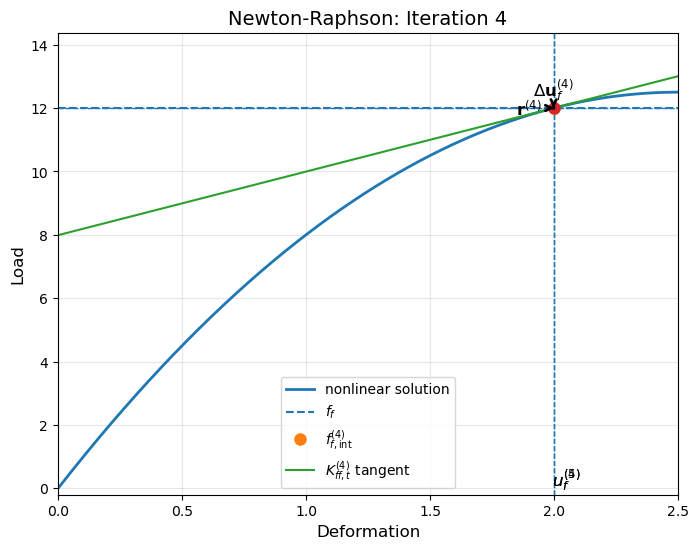

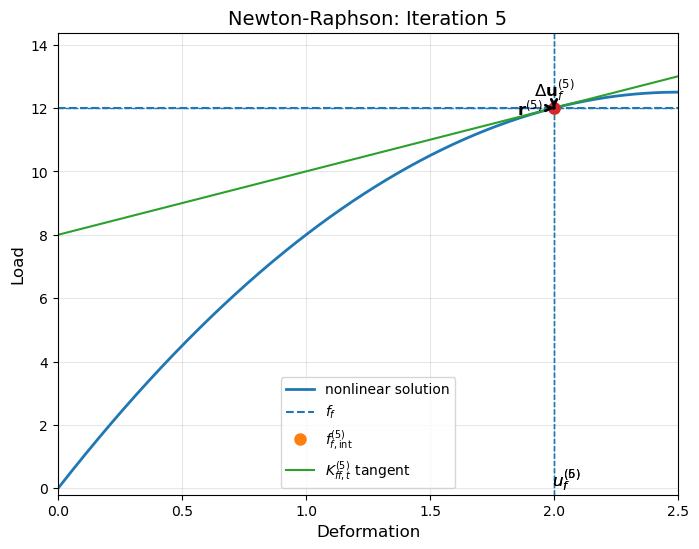

Converged: True
Final displacement: 2.000000

iter =  0, u^(0) = 0.000000, K_t^(0) = 10.000000, u^(1) = 1.200000
iter =  1, u_i = 1.200000, f_int = 9.120000, r = 2.880000, K_t = 5.200000, du = 0.553846, u_next = 1.753846, conv = 4.615385e-01
iter =  2, u_i = 1.753846, f_int = 11.386509, r = 0.613491, K_t = 2.984615, du = 0.205551, u_next = 1.959397, conv = 1.172002e-01
iter =  3, u_i = 1.959397, f_int = 11.915497, r = 0.084503, K_t = 2.162411, du = 0.039078, u_next = 1.998475, conv = 1.994386e-02
iter =  4, u_i = 1.998475, f_int = 11.996946, r = 0.003054, K_t = 2.006099, du = 0.001522, u_next = 1.999998, conv = 7.618020e-04
iter =  5, u_i = 1.999998, f_int = 11.999995, r = 0.000005, K_t = 2.000009, du = 0.000002, u_next = 2.000000, conv = 1.158911e-06


In [11]:

# ---------------------------------------------------------
# Example
# ---------------------------------------------------------

def f_int(u):
    return 10.0 * u - 2.0 * u**2

def K_t(u):
    return 10.0 - 4.0 * u

f_ext = 12.0
u_plot = np.linspace(0.0, 2.5, 500)

history, u_sol, converged = newton_raphson_1d(
    f_int=f_int,
    K_t=K_t,
    f_ext=f_ext,
    tol=1e-4,
    max_iter=10,
    u_plot=u_plot,
    make_plots=True,
)

print(f"Converged: {converged}")
print(f"Final displacement: {u_sol:.6f}")
print()

for h in history:
    if h["iter"] == 0:
        print(
            f"iter = {h['iter']:2d}, "
            f"u^(0) = {h['u_i']:.6f}, "
            f"K_t^(0) = {h['K_i']:.6f}, "
            f"u^(1) = {h['u_next']:.6f}"
        )
    else:
        print(
            f"iter = {h['iter']:2d}, "
            f"u_i = {h['u_i']:.6f}, "
            f"f_int = {h['f_int_i']:.6f}, "
            f"r = {h['r_i']:.6f}, "
            f"K_t = {h['K_i']:.6f}, "
            f"du = {h['du_i']:.6f}, "
            f"u_next = {h['u_next']:.6f}, "
            f"conv = {h['conv_measure']:.6e}"
        )